### Same as before:

In [1]:
import torch

x = torch.tensor([[1.0], [2.0], [3.0], [4.0]])
y_true = torch.tensor([[1.0], [4.0], [6.0], [8.0]])

In [2]:
import torch.nn as nn

class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)
        
    def forward(self, x):
        return self.linear(x)
    
model = SimpleNet()

#### Predictions BEFORE vs AFTER training

In [3]:
model(x)

tensor([[1.2120],
        [1.9602],
        [2.7085],
        [3.4568]], grad_fn=<AddmmBackward0>)

You’ll see:
- outputs are random
- nothing close to [2, 4, 6, 8]

Now train the model (same loop as before), then:

In [4]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

In [5]:
for epoch in range(20):
    
    y_pred = model(x)
    
    loss = loss_fn(y_pred, y_true)
    
    loss.backward()
    
    optimizer.step()
    
    optimizer.zero_grad()
    
    print(f"Epoch: {epoch}, Loss: {loss.item()}")

Epoch: 0, Loss: 8.920185089111328
Epoch: 1, Loss: 4.308148384094238
Epoch: 2, Loss: 2.2219855785369873
Epoch: 3, Loss: 1.2708063125610352
Epoch: 4, Loss: 0.8300687670707703
Epoch: 5, Loss: 0.6193172335624695
Epoch: 6, Loss: 0.5125843286514282
Epoch: 7, Loss: 0.45326825976371765
Epoch: 8, Loss: 0.41591358184814453
Epoch: 9, Loss: 0.38905152678489685
Epoch: 10, Loss: 0.36749544739723206
Epoch: 11, Loss: 0.3488820493221283
Epoch: 12, Loss: 0.3321166932582855
Epoch: 13, Loss: 0.3166770935058594
Epoch: 14, Loss: 0.3022993803024292
Epoch: 15, Loss: 0.2888375222682953
Epoch: 16, Loss: 0.2762001156806946
Epoch: 17, Loss: 0.264321893453598
Epoch: 18, Loss: 0.2531503140926361
Epoch: 19, Loss: 0.24264049530029297


In [6]:
model(x)

tensor([[1.9409],
        [3.9100],
        [5.8792],
        [7.8483]], grad_fn=<AddmmBackward0>)

You’ll see:
- outputs close to [2, 4, 6, 8]

This difference = learning.

### Visualizing prediction vs truth

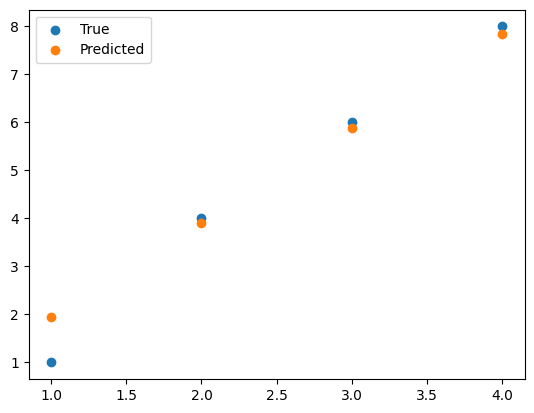

In [7]:
import matplotlib.pyplot as plt

with torch.no_grad():
    y_pred = model(x)

plt.scatter(x.numpy(), y_true.numpy(), label="True")
plt.scatter(x.numpy(), y_pred.numpy(), label="Predicted")
plt.legend()
plt.show()

What you should see:
- true points lie on a straight line
- predicted points almost overlap them

This means:
- model has learned the pattern
- weight ≈ slope
- bias ≈ shift

#### What torch.no_grad() actually means

It tells PyTorch:

“I promise I will NOT train here.
Just give me the output.”

So PyTorch:
- skips gradient tracking
- skips graph creation
- runs faster
- uses less memory

torch.no_grad() is used when you want predictions, not learning.

### Why visualization matters

Loss alone tells:
- “model is improving”

Plots tell:
- how it is improving
- where it fails
- if predictions make sense

In real projects:
- plots catch bugs faster than loss
- numbers can lie, visuals don’t

### Overfitting

Overfitting means:
- model memorizes training data
- performs badly on new data

Example:
- train only on `x = [1, 2, 3, 4]`
- test on `x = [100]`
- model fails badly

Why?
- model never saw such data

### How overfitting looks visually

- training points → predicted perfectly
- new points → completely off

This is why:
- train / validation split exists
- we test on unseen data

### Why this matters for games & big projects

In games:
- train on player behavior
- test on new players

If model overfits:
- game feels unfair
- AI breaks
- difficulty spikes

So we must test on unseen data.